<a href="https://colab.research.google.com/github/kshitij-nandanwar/OT-LAB/blob/main/OT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy as sp

# Define variables
x, y = sp.symbols('x y')

# Take input from user
function_input = input("Enter the function in terms of x and y (e.g., x**2 + y**2 - 4*x - 6*y + 13): ")
f = sp.sympify(function_input)

print("\nFunction:")
display(f)

# First partial derivatives
fx = sp.diff(f, x)
fy = sp.diff(f, y)

print("\nPartial Derivative wrt x:", fx)
print("Partial Derivative wrt y:", fy)

# Solve for stationary points
critical_points = sp.solve((fx, fy), (x, y))
print("\nStationary Point(s):", critical_points)

# Second partial derivatives
fxx = sp.diff(fx, x)
fyy = sp.diff(fy, y)
fxy = sp.diff(fx, y)

# Hessian determinant
D_expr = fxx*fyy - fxy**2

print("\nSecond Partial Derivatives:")
print(f"fxx = {fxx}, fyy = {fyy}, fxy = {fxy}")

# Standardize critical points to a list of dictionaries for robust processing
points_to_check = []
if isinstance(critical_points, dict):
    points_to_check = [critical_points]
elif isinstance(critical_points, list):
    for pt in critical_points:
        if isinstance(pt, dict):
            points_to_check.append(pt)
        elif isinstance(pt, tuple):
            points_to_check.append({x: pt[0], y: pt[1]})

# Classification
for pt in points_to_check:
    print(f"\nAnalyzing point {pt}:")
    val_D = D_expr.subs(pt)
    val_fxx = fxx.subs(pt)

    print(f"Hessian Determinant D = {val_D}")

    if val_D > 0:
        if val_fxx > 0:
            print("Result: Local Minimum")
        elif val_fxx < 0:
            print("Result: Local Maximum")
    elif val_D < 0:
        print("Result: Saddle Point")
    else:
        print("Result: Test is Inconclusive")

Enter the function in terms of x and y (e.g., x**2 + y**2 - 4*x - 6*y + 13): x**2 + y**2 - 4*x - 6*y + 13

Function:


x**2 - 4*x + y**2 - 6*y + 13


Partial Derivative wrt x: 2*x - 4
Partial Derivative wrt y: 2*y - 6

Stationary Point(s): {x: 2, y: 3}

Second Partial Derivatives:
fxx = 2, fyy = 2, fxy = 0

Analyzing point {x: 2, y: 3}:
Hessian Determinant D = 4
Result: Local Minimum


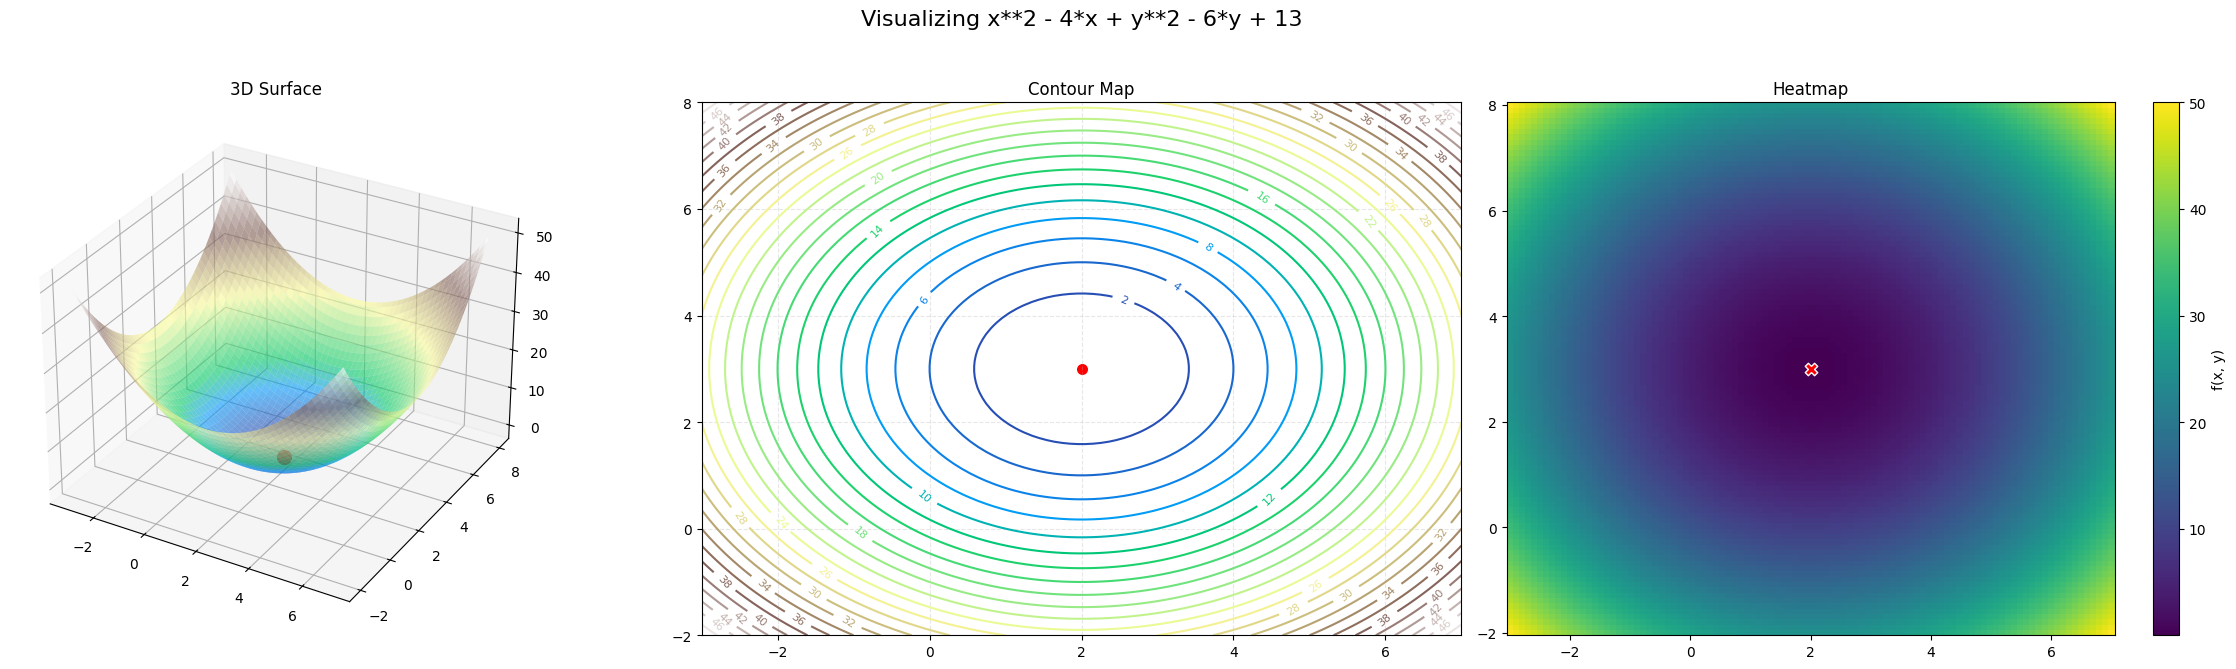

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert sympy function to a numeric function for plotting
f_num = sp.lambdify((x, y), f, 'numpy')

# Define the range for plotting (automatically covering all points found)
if points_to_check:
    all_x = [float(pt[x]) for pt in points_to_check if x in pt]
    all_y = [float(pt[y]) for pt in points_to_check if y in pt]

    x_center = sum(all_x) / len(all_x) if all_x else 0
    y_center = sum(all_y) / len(all_y) if all_y else 0

    if all_x and all_y:
        spread = max(max(all_x) - min(all_x), max(all_y) - min(all_y), 4)
    else:
        spread = 4
else:
    x_center, y_center, spread = 0, 0, 5

x_vals = np.linspace(x_center - spread - 1, x_center + spread + 1, 100)
y_vals = np.linspace(y_center - spread - 1, y_center + spread + 1, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_num(X, Y)

# Create a figure with three subplots
fig = plt.figure(figsize=(24, 7))

# --- 1. 3D Surface Plot ---
ax1 = fig.add_subplot(131, projection='3d')
surface = ax1.plot_surface(X, Y, Z, cmap='terrain', alpha=0.6)
for i, pt in enumerate(points_to_check):
    px, py = float(pt[x]), float(pt[y])
    pz = float(f.subs(pt))
    ax1.scatter(px, py, pz, color='red', s=100, label=f'Point {i+1}')
ax1.set_title('3D Surface')

# --- 2. 2D Contour Plot ---
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=30, cmap='terrain')
ax2.clabel(contour, inline=True, fontsize=8)
for i, pt in enumerate(points_to_check):
    px, py = float(pt[x]), float(pt[y])
    ax2.scatter(px, py, color='red', s=80, edgecolors='white', label=f'P{i+1}: ({px}, {py})')
ax2.set_title('Contour Map')
ax2.grid(True, linestyle='--', alpha=0.3)

# --- 3. 2D Heatmap ---
ax3 = fig.add_subplot(133)
heatmap = ax3.pcolormesh(X, Y, Z, cmap='viridis', shading='auto')
fig.colorbar(heatmap, ax=ax3, label='f(x, y)')
for i, pt in enumerate(points_to_check):
    px, py = float(pt[x]), float(pt[y])
    ax3.scatter(px, py, color='red', s=80, edgecolors='white', marker='X')
ax3.set_title('Heatmap')

plt.suptitle(f'Visualizing {f}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()